In [1]:
import os
import re
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.base import BaseEstimator, TransformerMixin

In [2]:
# ── 通道定義 & 五腦區分組 (與 svm_session_perturbation.ipynb 一致) ──

CH_NAMES = [
    'Fp1','Fz','F3','F7','FT9','FC5','FC1',
    'C3','T7','TP9','CP5','CP1','Pz','P3','P7',
    'O1','Oz','O2',
    'P4','P8','TP10','CP6','CP2','Cz','C4','T8',
    'FT10','FC6','FC2','F4','F8','Fp2'
]
SESSION_NAMES = ['ss01', 'ss02', 'ss03']
CLASS_NAMES = ['amateur', 'master', 'prof']

REGIONS = {
    'Frontal':   [0, 31, 2, 29, 3, 30, 1],
    'Central':   [7, 24, 23, 6, 28, 5, 27],
    'Parietal':  [13, 18, 14, 19, 12, 11, 22, 10, 21],
    'Temporal':  [8, 25, 4, 26, 9, 20],
    'Occipital': [15, 17, 16],
}

In [3]:
# ── EEG 資料載入 (與原本完全一致) ──

def get_subject_id(filename):
    return filename.split('_ses-')[0]

def scan_session_folder(folder_path):
    result = {}
    for fname in sorted(os.listdir(folder_path)):
        if fname.endswith('.mat'):
            result[get_subject_id(fname)] = os.path.join(folder_path, fname)
    return result

def load_band_energy(filepath):
    with h5py.File(filepath, 'r') as f:
        data = np.array(f['band_energy']).T
    return data

def load_group(ss01_map, ss02_map, ss03_map, complete_subs):
    X1, X2, X3 = [], [], []
    for sub_id in complete_subs:
        X1.append(load_band_energy(ss01_map[sub_id]))
        X2.append(load_band_energy(ss02_map[sub_id]))
        X3.append(load_band_energy(ss03_map[sub_id]))
    return np.array(X1), np.array(X2), np.array(X3)

BASE_AMATEUR = r'D:\Tseng\圍棋\amateur\band_energy_batch_outputs_2026'
BASE_MASTER  = r'D:\Tseng\圍棋\master\band_energy_batch_outputs_2026'
BASE_PROF    = r'D:\Tseng\圍棋\prof\band_energy_batch_outputs_2026'

PATHS = {
    'amateur': {s: os.path.join(BASE_AMATEUR, s) for s in SESSION_NAMES},
    'master':  {s: os.path.join(BASE_MASTER,  s) for s in SESSION_NAMES},
    'prof':    {s: os.path.join(BASE_PROF,    s) for s in SESSION_NAMES},
}

maps = {}
complete = {}
for group in CLASS_NAMES:
    m1 = scan_session_folder(PATHS[group]['ss01'])
    m2 = scan_session_folder(PATHS[group]['ss02'])
    m3 = scan_session_folder(PATHS[group]['ss03'])
    maps[group] = (m1, m2, m3)
    complete[group] = sorted(set(m1) & set(m2) & set(m3))
    print(f'[{group}] EEG 完整 subject：{len(complete[group])} 人')

print('\n載入 EEG 資料...')
X_a1, X_a2, X_a3 = load_group(*maps['amateur'], complete['amateur'])
X_m1, X_m2, X_m3 = load_group(*maps['master'],  complete['master'])
X_p1, X_p2, X_p3 = load_group(*maps['prof'],    complete['prof'])
print(f'完成  shape: {X_a1.shape}  (n_sub, 32ch, 39time, 5bands)')

[amateur] EEG 完整 subject：28 人
[master] EEG 完整 subject：20 人
[prof] EEG 完整 subject：8 人

載入 EEG 資料...
完成  shape: (28, 32, 39, 5)  (n_sub, 32ch, 39time, 5bands)


In [4]:
# ── EEG 特徵提取 ──

def extract_mean_3d(X):
    """(n, 32ch, 39time, 5bands) -> (n, 32, 5)"""
    X = np.log(X + 1e-8)
    X = X[:, :, 1:-1, :]
    return X.mean(axis=2)

n_a = len(complete['amateur'])
n_m = len(complete['master'])
n_p = len(complete['prof'])
n_total = n_a + n_m + n_p

raw = {
    'amateur': [X_a1, X_a2, X_a3],
    'master':  [X_m1, X_m2, X_m3],
    'prof':    [X_p1, X_p2, X_p3],
}

# 排列：amateur_ss01, amateur_ss02, amateur_ss03, master_ss01, ..., prof_ss03
feats_3d = []
for g in CLASS_NAMES:
    for Xr in raw[g]:
        feats_3d.append(extract_mean_3d(Xr))
X_3d = np.vstack(feats_3d)  # (168, 32, 5)

y_all = np.concatenate([np.zeros(n_a * 3), np.ones(n_m * 3), np.full(n_p * 3, 2)])
subject_ids = complete['amateur'] + complete['master'] + complete['prof']
subject_split = np.concatenate([
    np.repeat(complete['amateur'], 3),
    np.repeat(complete['master'], 3),
    np.repeat(complete['prof'], 3),
])
subject_labels = {}
for g_idx, g in enumerate(CLASS_NAMES):
    for s in complete[g]:
        subject_labels[s] = g_idx

print(f'X_3d shape: {X_3d.shape}')
print(f'Total subjects: {n_total}  (Amateur: {n_a}, Master: {n_m}, Prof: {n_p})')

X_3d shape: (168, 32, 5)
Total subjects: 56  (Amateur: 28, Master: 20, Prof: 8)


In [5]:
# ── 載入 RT 資料並對齊 EEG subject 排列 ──

def extract_real_subject(source):
    m = re.match(r'(sub-\w+?)_ses-', source)
    return m.group(1) if m else source

def extract_session(source):
    m = re.search(r'_ses-[Ss]?[Ee]?[Ss]?[Ss]?0*(\d+)', source)
    return int(m.group(1)) if m else None

# 讀取所有 RT 資料
rt_dfs = []
for g in CLASS_NAMES:
    df = pd.read_csv(f'D:/Tseng/圍棋/Integrated_RT_Results_with_Order.{g}.csv')
    df['Group'] = g
    df['RT_diff_ms'] = df['RT2_ms'] - df['RT1_ms']
    df['RealSubject'] = df['SourceFile'].apply(extract_real_subject)
    df['Session'] = df['SourceFile'].apply(extract_session)
    rt_dfs.append(df)
df_rt = pd.concat(rt_dfs, ignore_index=True)

# 建立 RT lookup: (subject, session) -> mean RT
rt_lookup = df_rt.groupby(['RealSubject', 'Session'])['RT_diff_ms'].mean().to_dict()

# 按 EEG 的排列順序建立 RT 特徵向量
# 排列：amateur_ss01, amateur_ss02, amateur_ss03, master_ss01, ...
rt_features = []
missing_rt = []
for g in CLASS_NAMES:
    for ss_idx, ss_num in enumerate([1, 2, 3]):
        for sub_id in complete[g]:
            key = (sub_id, ss_num)
            if key in rt_lookup:
                rt_features.append(rt_lookup[key])
            else:
                rt_features.append(np.nan)
                missing_rt.append((sub_id, ss_num))

RT_vec = np.array(rt_features).reshape(-1, 1)  # (168, 1)

n_missing = np.isnan(RT_vec).sum()
print(f'RT feature shape: {RT_vec.shape}')
print(f'Missing RT values: {n_missing}')
if n_missing > 0:
    print(f'Missing subjects: {missing_rt}')
    # 用該 subject 其他 session 的平均值填補
    for sub_id, ss_num in missing_rt:
        other_vals = [rt_lookup.get((sub_id, s), np.nan) for s in [1,2,3] if s != ss_num]
        other_vals = [v for v in other_vals if not np.isnan(v)]
        fill_val = np.mean(other_vals) if other_vals else np.nanmean(RT_vec)
        # 找到對應位置填入
        idx = np.where(np.isnan(RT_vec))[0]
        for i in idx:
            RT_vec[i] = fill_val
        print(f'  Filled {sub_id} ss{ss_num:02d} with {fill_val:.1f} ms')

print(f'\nRT stats: mean={np.mean(RT_vec):.1f}, std={np.std(RT_vec):.1f}')

RT feature shape: (168, 1)
Missing RT values: 0

RT stats: mean=2440.8, std=1377.4


In [6]:
# ── 自定義 Transformer：分離處理 EEG 和 RT ──

class ColumnSelector(BaseEstimator, TransformerMixin):
    """選取指定欄位的 Transformer"""
    def __init__(self, columns):
        self.columns = columns
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        return X[:, self.columns]


def run_loso_multimodal(X_eeg, X_rt, y_all, subject_split, subject_ids, subject_labels):
    """
    EEG -> Scaler + PCA(40)
    RT  -> Scaler
    合併後 -> SVM
    """
    n_eeg = X_eeg.shape[1]
    pca_n = min(40, n_eeg)
    X_combined = np.hstack([X_eeg, X_rt])  # (N, n_eeg+1)
    eeg_cols = list(range(n_eeg))
    rt_cols  = list(range(n_eeg, n_eeg + X_rt.shape[1]))

    all_preds, all_true = [], []
    per_sub = []

    for test_subject in subject_ids:
        test_mask  = subject_split == test_subject
        train_mask = ~test_mask

        X_tr, y_tr = X_combined[train_mask], y_all[train_mask].astype(int)
        X_te, y_te = X_combined[test_mask],  y_all[test_mask].astype(int)

        pipe = Pipeline([
            ('features', FeatureUnion([
                ('eeg', Pipeline([
                    ('select', ColumnSelector(eeg_cols)),
                    ('scaler', StandardScaler()),
                    ('pca',    PCA(n_components=pca_n)),
                ])),
                ('rt', Pipeline([
                    ('select', ColumnSelector(rt_cols)),
                    ('scaler', StandardScaler()),
                ])),
            ])),
            ('clf', SVC(kernel='rbf', C=10, gamma='scale',
                        class_weight='balanced', random_state=42)),
        ])
        pipe.fit(X_tr, y_tr)
        preds = pipe.predict(X_te)

        acc = accuracy_score(y_te, preds)
        f1  = f1_score(y_te, preds, average='macro', zero_division=0)
        per_sub.append({'acc': acc, 'f1': f1, 'subject': test_subject,
                        'true': subject_labels[test_subject]})
        all_preds.extend(preds)
        all_true.extend(y_te)

    all_preds = np.array(all_preds)
    all_true  = np.array(all_true)
    mean_acc = np.mean([r['acc'] for r in per_sub])
    mean_f1  = np.mean([r['f1']  for r in per_sub])
    return mean_acc, mean_f1, per_sub, all_preds, all_true


def run_loso_eeg_only(X_eeg, y_all, subject_split, subject_ids, subject_labels):
    """EEG baseline (與原本一致)"""
    pca_n = min(40, X_eeg.shape[1])
    all_preds, all_true = [], []
    per_sub = []

    for test_subject in subject_ids:
        test_mask  = subject_split == test_subject
        train_mask = ~test_mask

        X_tr, y_tr = X_eeg[train_mask], y_all[train_mask].astype(int)
        X_te, y_te = X_eeg[test_mask],  y_all[test_mask].astype(int)

        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('pca',    PCA(n_components=pca_n)),
            ('clf',    SVC(kernel='rbf', C=10, gamma='scale',
                           class_weight='balanced', random_state=42)),
        ])
        pipe.fit(X_tr, y_tr)
        preds = pipe.predict(X_te)

        acc = accuracy_score(y_te, preds)
        f1  = f1_score(y_te, preds, average='macro', zero_division=0)
        per_sub.append({'acc': acc, 'f1': f1, 'subject': test_subject,
                        'true': subject_labels[test_subject]})
        all_preds.extend(preds)
        all_true.extend(y_te)

    all_preds = np.array(all_preds)
    all_true  = np.array(all_true)
    mean_acc = np.mean([r['acc'] for r in per_sub])
    mean_f1  = np.mean([r['f1']  for r in per_sub])
    return mean_acc, mean_f1, per_sub, all_preds, all_true

In [7]:
# ── 五腦區比較：EEG-only vs EEG+RT ──

results = {}

print(f'{"Region":<13s} {"":<6s} {"EEG-only":>12s} {"EEG+RT":>12s} {"Diff":>8s}')
print(f'{"":<13s} {"":<6s} {"Acc / F1":>12s} {"Acc / F1":>12s} {"Acc":>8s}')
print('-' * 60)

for region_name, ch_idx in REGIONS.items():
    X_eeg = X_3d[:, ch_idx, :].reshape(len(X_3d), -1)

    # EEG only
    acc_e, f1_e, ps_e, preds_e, true_e = run_loso_eeg_only(
        X_eeg, y_all, subject_split, subject_ids, subject_labels
    )
    # EEG + RT
    acc_m, f1_m, ps_m, preds_m, true_m = run_loso_multimodal(
        X_eeg, RT_vec, y_all, subject_split, subject_ids, subject_labels
    )

    results[region_name] = {
        'eeg_only': {'acc': acc_e, 'f1': f1_e, 'preds': preds_e, 'true': true_e},
        'eeg_rt':   {'acc': acc_m, 'f1': f1_m, 'preds': preds_m, 'true': true_m},
    }

    diff = acc_m - acc_e
    print(f'{region_name:<13s} {len(ch_idx):2d}ch  '
          f'{acc_e:.3f}/{f1_e:.3f}   {acc_m:.3f}/{f1_m:.3f}   {diff:+.3f}')

Region                   EEG-only       EEG+RT     Diff
                         Acc / F1     Acc / F1      Acc
------------------------------------------------------------
Frontal        7ch  0.679/0.550   0.702/0.556   +0.024
Central        7ch  0.649/0.493   0.720/0.577   +0.071
Parietal       9ch  0.756/0.635   0.744/0.607   -0.012
Temporal       6ch  0.589/0.444   0.690/0.544   +0.101
Occipital      3ch  0.565/0.422   0.542/0.374   -0.024


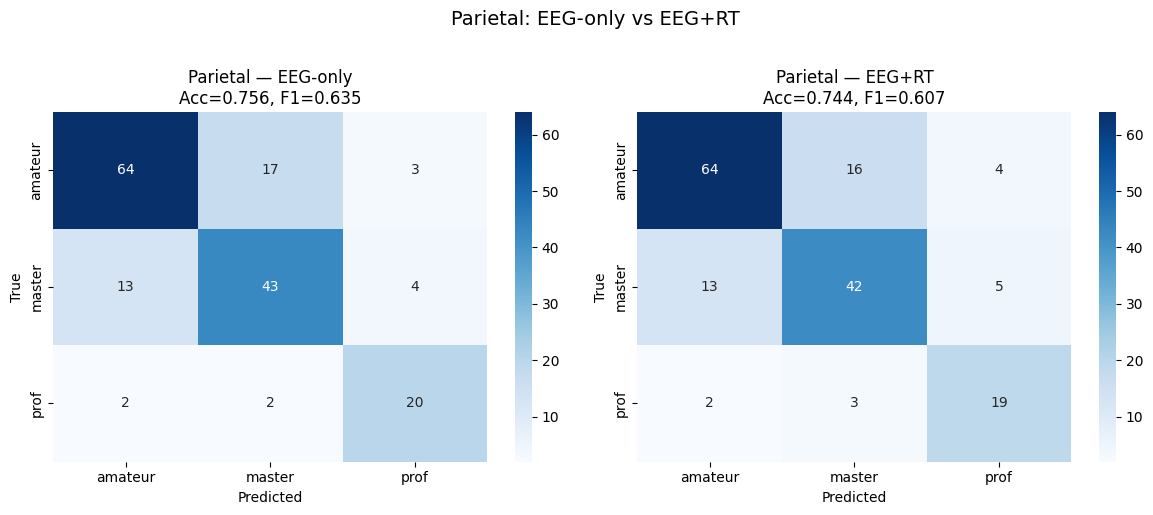

In [8]:
# ── Confusion Matrix 比較：以 Parietal (最佳腦區) 為例 ──

best_region = 'Parietal'
r = results[best_region]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (label, key) in zip(axes, [('EEG-only', 'eeg_only'), ('EEG+RT', 'eeg_rt')]):
    cm = confusion_matrix(r[key]['true'], r[key]['preds'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(f'{best_region} — {label}\nAcc={r[key]["acc"]:.3f}, F1={r[key]["f1"]:.3f}')

plt.suptitle(f'{best_region}: EEG-only vs EEG+RT', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(r'D:\Tseng\game_eeg\game_RT_time\multimodal_confusion_parietal.png',
            dpi=150, bbox_inches='tight')
plt.show()

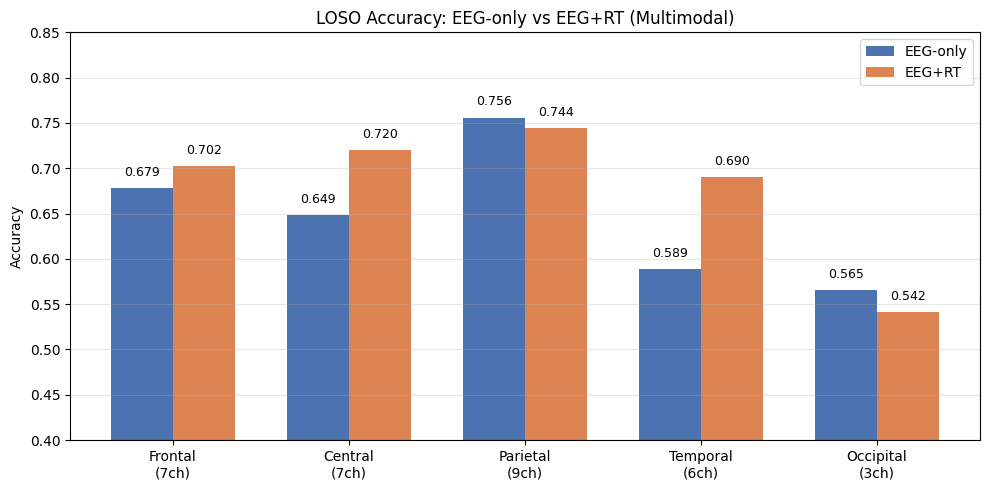

In [9]:
# ── Grouped bar chart：五腦區的 EEG-only vs EEG+RT ──

region_names = list(REGIONS.keys())
acc_eeg = [results[rn]['eeg_only']['acc'] for rn in region_names]
acc_multi = [results[rn]['eeg_rt']['acc'] for rn in region_names]

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(region_names))
width = 0.35

ax.bar(x - width/2, acc_eeg,   width, label='EEG-only',  color='#4C72B0')
ax.bar(x + width/2, acc_multi, width, label='EEG+RT',    color='#DD8452')

ax.set_xticks(x)
ax.set_xticklabels([f'{rn}\n({len(REGIONS[rn])}ch)' for rn in region_names])
ax.set_ylabel('Accuracy')
ax.set_title('LOSO Accuracy: EEG-only vs EEG+RT (Multimodal)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0.4, 0.85)

# 在每個 bar 上標註數值
for i, (e, m) in enumerate(zip(acc_eeg, acc_multi)):
    ax.text(i - width/2, e + 0.01, f'{e:.3f}', ha='center', va='bottom', fontsize=9)
    ax.text(i + width/2, m + 0.01, f'{m:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(r'D:\Tseng\game_eeg\game_RT_time\multimodal_comparison_bar.png',
            dpi=150, bbox_inches='tight')
plt.show()

All 32ch Results:
  EEG-only:  Acc=0.780  F1=0.634
  EEG+RT:    Acc=0.810  F1=0.688
  Diff:      Acc=+0.030  F1=+0.054


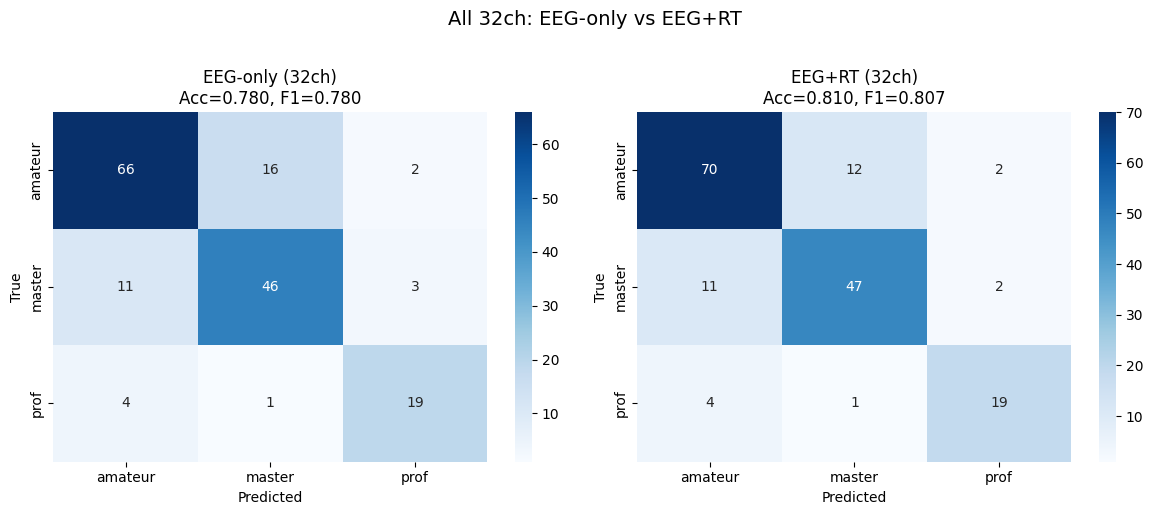

In [10]:
# ── 全 32ch EEG vs 全 32ch EEG+RT ──

all_ch = list(range(32))
X_eeg_all = X_3d[:, all_ch, :].reshape(len(X_3d), -1)

acc_e, f1_e, _, preds_e, true_e = run_loso_eeg_only(
    X_eeg_all, y_all, subject_split, subject_ids, subject_labels
)
acc_m, f1_m, _, preds_m, true_m = run_loso_multimodal(
    X_eeg_all, RT_vec, y_all, subject_split, subject_ids, subject_labels
)

print(f'All 32ch Results:')
print(f'  EEG-only:  Acc={acc_e:.3f}  F1={f1_e:.3f}')
print(f'  EEG+RT:    Acc={acc_m:.3f}  F1={f1_m:.3f}')
print(f'  Diff:      Acc={acc_m - acc_e:+.3f}  F1={f1_m - f1_e:+.3f}')

# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (label, preds, true) in zip(axes,
    [('EEG-only (32ch)', preds_e, true_e), ('EEG+RT (32ch)', preds_m, true_m)]):
    cm = confusion_matrix(true, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    acc = accuracy_score(true, preds)
    f1 = f1_score(true, preds, average='macro', zero_division=0)
    ax.set_title(f'{label}\nAcc={acc:.3f}, F1={f1:.3f}')

plt.suptitle('All 32ch: EEG-only vs EEG+RT', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(r'D:\Tseng\game_eeg\game_RT_time\multimodal_confusion_32ch.png',
            dpi=150, bbox_inches='tight')
plt.show()